In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gráficos de funções de duas variáveis

## $ \S 1 $ Introdução

Muitas quantidades dependem de mais de uma variável.  Por exemplo, a área de uma
chapa retangular é dada pelo produto do seu comprimento e da sua largura. O
brilho de uma estrela vista da Terra depende da sua distância e luminosidade. A
função $ V = \pi r^2 h $ expressa o volume de uma lata cilíndrica em termos do
seu raio $ r $ e da sua altura $ h $. Similarmente, $ f(x, y) = x^2 + y^2 $
calcula a altura $ z $ de um parabolóide acima do ponto $ (x, y) $ em $ \mathbb
R^2 $.


__Exemplo (função de Cobb-Douglas):__
A _função de produção de Cobb-Douglas_ é utilizada em economia para
modelar a relação entre dois ou mais insumos, geralmente capital e trabalho, e a
quantidade de produto resultante. A sua forma geral é:
$$
    Q(C, T) = A  C^\alpha T^\beta\,, \qquad \text{onde}
$$
* $ Q $ é a quantidade do produto final.
* $ C $ é a quantidade de capital despendido.
* $ T $ é a quantidade de trabalho.
* $ A $ é uma constante, que representa a produtividade ou eficiência tecnológica.
* $ \alpha $ e $ \beta $ são os expoentes (constantes) que indicam a elasticidade da produção
  em relação ao capital e ao trabalho, respectivamente.

Observe que apesar de $ Q $ depender de vários parâmetros, apenas $ C $ e $ T $
_não_ são constantes. Dizemos que estas são as __variáveis independentes__, e que
portanto $ Q $ é uma função de $ C $ e $ T $. Um economista procuraria
entender como a __variável dependente__ $ Q $ muda de valor conforme $ C $ e $ T
$ variam, para tirar conclusões a respeito da situação concreta à qual
este modelo está sendo aplicado.

O __domínio__ $ D \subseteq \mathbb R^2 $ de uma função $ f $ de duas variáveis
é o conjunto dos pontos $ (x, y) $ para os quais ela está definida. Escrevemos
$ f \colon D \to \mathbb R $ para indicar que $ f $ é uma função real definida
em $ D $, e representamos $ D $ como uma região no plano-$ xy $.

O __gráfico__ $ G_f $ de uma função de duas variáveis $ f $ é o conjunto de
todos os pontos $ (x, y, z) $ no espaço tridimensional $\mathbb{R}^3$ tais que
$ z $ é o valor de $ f $ em $ (x, y) $, ou seja,
$$
G_f = \{ (x, y, z) \in D : (x, y) \in D \text{ e } z = f(x, y) \}\,.
$$
Geometricamente, o gráfico de uma função de duas variáveis pode ser interpretado
como uma superfície bidimensional no espaço ambiente $ \mathbb R^3 $, tal que a
sua altura $ z $ acima de um ponto $ (x, y) $ no plano-$ xy $ é dada por $ z =
f(x, y) $.

Visualizar o gráfico de uma função de duas variáveis nos ajuda a entender melhor
como a função se comporta. Em particular, gráficos são extremamente úteis para
se identificar características como máximos, mínimos, pontos de sela e o comportamento
global da função.

## $ \S 2 $ Visualizando gráficos de funções de duas variáveis

Recorde que para desenhar o gráfico de uma função $ y = f(x) $ de _uma_
variável usando a Matplotlib, o procedimento era o seguinte:
1. Geramos um número $ N $ de pontos $ x $ igualmente
   espaçados dentro do intervalo de interesse no domínio da função, e os
   armazenamos num seqüência `xs`.
2. Avaliamos $ f $ em cada um destes valores para obter a coordenada
   $ y = f(x) $ correspondente, e armazenamos todos estes valores em outra
   seqüência `ys`.
3. Finalmente, conectamos $ \big(x_i, y_i\big) $ a
   $ \big(x_{i + 1}, y_{i + 1}\big) $ por um _segmento de reta_ para cada $ i $.
   A coleção de todos estes segmentos aproxima o gráfico de $ f $.

<p align="center">
  <img src="grafico_de_funcao_de_uma_variavel.png" width="800">
  <br>
  <em>Figura 1: Aproximando um gráfico por segmentos de retas</em>
</p>

Para construir gráficos de funções de duas variáveis, o procedimento é análogo:
1. Criamos uma _malha_ (_mesh_, em inglês) de pontos no plano-$ xy $, ou seja,
   uma amostra de pares $ (x_i, y_j) $ no domínio da função. Para isto 
   utilizamos o procedimento `np.meshgrid`.
2. Calculamos os valores $ z = f(x, y) $ em cada ponto $ (x_i, y_j) $ pertencente à malha.
3. Construímos o gráfico de $ f $ em $ \mathbb R^3 $ a partir destes valores por
   interpolação.
   
Na forma mais simples, a superfície resultante é constituída de vários
_triângulos_ em $ \mathbb R^3 $ colados uns aos outros ao longo de arestas (em
analogia aos segmentos de reta utilizados para construir gráficos de funções de
apenas uma variável).  Em geral, quanto mais refinada for a malha de pontos,
mais suave será a aparência e melhor será a aproximação desta superfície ao
gráfico de $ f $.
<p align="center">
  <img src="triangulacao.png" width="1000">
  <br>
  <em>Figura 1: Aproximando um gráfico de uma função de duas variáveis por triângulos</em>
</p>

📝 Por que usar triângulos e não outra superfície como bloco de
construção de gráficos? Além da simplicidade, o motivo principal é que
_três pontos determinam univocamente um plano_, portanto se sabemos que
$ (x_1, y_1, z_1) $, $ (x_2, y_2, z_2) $ e $ (x_3, y_3, z_3) $ pertencem ao
gráfico de $ f $, podemos interpolar _linearmente_ as imagens de pontos
no triângulo $ T \subset D $ de vértices $ (x_1, y_1) $, $ (x_2, y_2) $ e 
$ (x_3, y_3) $. Ou seja, podemos preencher as imagens de pontos
de $ T $ a partir daquelas dos seus vértices. Se utilizarmos mais de $ 3 $
pontos como pivôs, não há uma maneira óbvia de interpolar linearmente os valores
de $ f $. Matematicamente, podemos escrever qualquer ponto $ (x, y) $ em $ T $ como:
$$
    (x, y) = t_1(x_1, y_1) + t_2(x_2, y_2) + t_3(x_3, y_3) \quad \text{onde $ t_i \in [0, 1] $ e $ t_1 + t_2 + t_3 = 1 $}\,.
$$
Por exemplo, tomando $ t_1 = t_2 = t_3 = \frac{1}{3} $, o ponto resultante é o
baricentro do triângulo. Similarlmente, fazendo $ t_1 = 0 $ e
escolhendo $ t_2 \in [0, 1] $ qualquer, $ t_3 = 1 - t_2 $, conseguimos parametrizar
a aresta do triângulo conectando $ (x_2, y_2) $ a $ (x_3, y_3) $.

Em geral, os números $ t_i $ são univocamente
determinados pelo ponto $ (x,y) $ pertencente ao triângulo. Sendo assim, é
natural aproximarmos
$ f(x, y) $ por $$ t_1z_1 + t_2 z_2 + t_3 z_3 \quad \text{onde $ z_i = f(x_i, y_i)
$}\,. $$ A aproximação para a imagem  $ f(T) $ do triângulo $ T $ assim obtida é
novamente um triângulo, desta vez em $ \mathbb{R}^3 $, de vértices $ (x_1,y_1,
z_1) $, $ (x_2, y_2, z_2) $ e $ (x_3, y_3, z_3) $.

__Exemplo 1:__ Vamos exibir o gráfico da função $ f(x, y) = \sin x \cos y $:

In [ ]:
# Importando as bibliotecas necessárias:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a função de duas variáveis:
f = lambda x, y: np.sin(x) * np.cos(y)

# Criando a grade de pontos (x, y):
M = 100
N = 200
xs = np.linspace(-4, 4, M)    # M = 100 valores de x igualmente espaçados em [-4, 4]
ys = np.linspace(-6, 6, N)    # N = 200 valores de y igualmente espaçados em [-6, 6]
X, Y = np.meshgrid(xs, ys)      # Matrizes 100 x 200 contendo valores de x e y, resp.
# Calculando os valores de z correspondentes:
Z = f(X, Y)     # Z também é uma matriz de dimensões 100 x 200

# Criando a figura (tela) onde o gráfico será exibido:
fig = plt.figure(figsize=(12, 7))
# Adicionando um retângulo para plotagem dentro desta figura:
ax = fig.add_subplot(1, 1, 1, projection="3d")
# Este comando é necessário porque é possível subdividir um única figura/tela em
# várias retângulos e plotar um gráfico dentro de cada uma delas:

# Plotando o gráfico:
grafico = ax.plot_surface(X, Y, Z, cmap="coolwarm")
# `cmap` é abreviação de "color map" (mapa de cor), e configura as cores
# utilizadas. Há várias opções; algumas das mais comuns são: `viridis`,
# `cividis`, `magma`, `jet`, `inferno`, `plasma`, `cool` e `coolwarm`.

# Adicionando uma barra de cores para ajudar na interpretação:
fig.colorbar(grafico, shrink=0.5)  # reduzir o tamanho para 50%

# Configurando os comprimentos relativos dos três eixos,
# adicionando rótulos aos eixos e um título:
ax.set_box_aspect([3, 3, 1])  # [x, y, z]
ax.set_xlabel("$ x $")
ax.set_ylabel("$ y $")
ax.set_zlabel("$ z = f(x, y) $")
ax.set_title("Meu Primeiro gráfico $ 3D $")

# Mostrando o gráfico:
plt.show()

📝 Para mais detalhes sobre as opções de mapas de cores, veja a [documentação do Matplotlib](https://matplotlib.org/stable/gallery/color/colormap_reference.html).

__Exercício:__ Verifique que as superfícies construídas desta forma pela
Matplotlib são na verdade retalhos de triângulos ou quadriláteros diminuindo a
resolução do gráfico, i.e., o número de pontos em `xs` e `ys`. Utilize por
exemplo $ M = 5 $ e $ N = 5 $ no código acima.

Por padrão, `plot_surface` utiliza retalhos quadrilaterais, não triangulares,
mas a idéia é essencialmente a mesma que a ilustrada acima usando triangulacões.
A diferença principal é que para preencher cada quadrilátero, é
utilizada uma interpolação _bilinear_ em vez de linear.

Mais especificamente, considere um ponto $(x, y)$ dentro do quadrilátero da malha
no domínio com vértices em $(x_0, y_0)$, $(x_1, y_0)$, $(x_0, y_1)$ e $(x_1, y_1)$
e valores de $ z $ correspondentes $z_{00}$, $z_{10}$, $z_{01}$ e $z_{11}$. Então o
valor de $ z $ interpolado em $ (x, y) $ é calculado como:
$$
  z(x, y) = (1-s)(1-t)z_{00} + s(1-t)z_{10} + (1-s)tz_{01} + stz_{11}
$$
onde
\begin{alignat*}{9}
  s &= \frac{x - x_0}{x_1 - x_0} \in [0, 1] & & \quad \text{(posição fracionária na direção $ x $)} \\
  t &= \frac{y - y_0}{y_1 - y_0} \in [0, 1] & & \quad \text{(posição fracionária na direção $ y $)}
\end{alignat*}
Isto significa que $ f(x, y) $ é aproximado por uma média ponderada dos valores de $ f $
nos quatro vértices. A interpolação bilinear cria uma superfície quadrilateral
que não é plana em geral, ao contrário do que ocorre no caso em que a malha é
triangular.
<p align="center">
  <img src="resolucao.png" width="1200">
  <br>
  <em>Figura 2: Estudando o efeito da densidade da malha de pontos na suavidade da superfície</em>
</p>

📝 O procedimento `meshgrid` toma dois vetores como entrada e retorna duas matrizes
que representam as coordenadas da malha. Por exemplo:

In [ ]:
xs = np.array([1, 2, 3, 4])
ys = np.array([0, 10])

X, Y = np.meshgrid(xs, ys)
print(f"Matriz X resultante:\n{X}\n")
print(f"Matriz Y resultante:\n{Y}\n")

Assim:
* A matriz `X` repete o array `xs` ao longo das linhas, com uma linha para cada elemento de `ys`.
* A matriz `Y` repete o vetor `ys` ao longo das colunas, com uma coluna para cada elemento de `xs`.

Observe que elas têm a mesma dimensão $ m \times n $, onde $ m $
(resp. $ n $) é o comprimento de `xs` (resp. `ys`). Portanto se parearmos as
duas matrizes elemento a elemento, obteremos uma matriz $ P $ dos pontos $ (x,
y) $ desejados, onde $ P_{ij} = (x_{i}, y_{j}) $. Depois basta avaliar $ f $ em
cada um destes pontos. Mas com o NumPy podemos pular a construção de $ P $ e
simplesmente avaliar $ f $ em `X` e `Y` diretamente. Por exemplo:

In [ ]:
# Vamos tomar f como sendo a função soma:
f = lambda x, y: x + y

print(f(X, Y))
# De novo a dimensão é m x n. A (i, j)-ésima entrada é f(x_i, y_j)

__Exercício:__ Este exercício ilustra que também podemos visualizar superfícies
que não são gráficos. Usando o Exemplo $ 1 $ como modelo, complete o código abaixo
para plotar a _superfície de Enneper_, descrita pelas equações paramétricas
$$
\begin{align*}
x(u,v) &= u - \frac{u^3}{3} + uv^2 \\
y(u,v) &= v - \frac{v^3}{3} + vu^2 \\
z(u,v) &= u^2 - v^2
\end{align*} \qquad (u,\,v \in \mathbb{R})
$$
Na mesma figura/tela, plote também o _catenóide_, descrito pelas equações
$$
\begin{align*}
x(u, v) &= \cosh(u) \cos(v) \\
y(u, v) &= \cosh(u) \sin(v) \\
z(u, v) &= u
\end{align*}
$$

In [ ]:
# Criando a figura e eixo 3D:
fig = plt.figure(figsize=(12, 7))
# Vamos plotar as duas superfícies lado a lado:
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
# (1, 2, 1): uma linha, duas colunas, acessar o primeiro retângulo

# --- SUPERFÍCIE DE ENNEPER ---
# Defina os valores de u e v dentro do intervalo [-10, 10] usando o `np.linspace`:
# us_e = ...
# vs_e = ...
# Defina as matrizes U e V correspondentes usando o `np.meshgrid`:
# U_e, V_e = ...

# Definindo parametricamente a superfície de Enneper:
# X_e = U_e - (U_e**3) / 3 + U_e * (V_e**2)
# Y_e = ...
# Z_e = ...

# Plotando a superfície de Enneper:
enneper = ax1.plot_surface(X_e, Y_e, Z_e, cmap="cividis", 
                           linewidth=0, antialiased=True, alpha=0.8)
# Adicionando uma barra de cores:
fig.colorbar(enneper, ax=ax1, shrink=0.5, aspect=10)

# Definindo rótulos e o título:
ax1.set_xlabel("$ x $")
ax1.set_ylabel("$ y $")
ax1.set_zlabel("$ z $")
ax1.set_title("Superfície de Enneper")
# Ajustando os ângulos de visualização para melhor perspectiva:
ax1.view_init(elev=15, azim=45)

# --- CATENÓIDE ---
# Adicionando a segunda área de plotagem para o catenóide:
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

# Definindo os parâmetros para o catenóide:
# Tome 100 valores de u no intervalo [-1, 1]:
# us_c = ...
# Tome 200 valores de v no intervalo [0, 2π]:
# vs_c = ...
# Defina as matrizes U_c e V_c que descrevem a malha de pontos (u, v):
# U_c, V_c = ...

# Parametrize o catenóide usando cosh e sinh do NumPy:
# X_c = ...
# Y_c = ...
# Z_c = ...

# Plotando a superfície do catenoide:
catenoide = ax2.plot_surface(X_c, Y_c, Z_c, cmap="viridis",
                             linewidth=0, antialiased=True, alpha=0.8)
fig.colorbar(catenoide, ax=ax2, shrink=0.5, aspect=10)
ax2.set_title("Catenóide")
ax2.set_xlabel("$ x $")
ax2.set_ylabel("$ y $")
ax2.set_zlabel("$ z $")
ax2.set_box_aspect([1, 1, 1])
ax2.view_init(elev=15, azim=45)

plt.tight_layout()
plt.show()

📝 O método `add_subplot()` é usado para adicionar uma área de plotagem (um objeto
de tipo `Axes`) a uma tela (um objeto de tipo `Figure`), organizada dentro de
uma grade de uma ou mais áreas deste tipo (subplots). A sintaxe é:
```
fig.add_subplot(n_linhas, n_cols, índice, **kwargs)
```
onde aqui:
- `n_linhas` é o número de linhas na grade de subplots.
- `n_cols` é o número de colunas na grade de subplots.
- `índice` é a posição do subplot dentro da grade. Os índices começam em $ 1 $ no
   canto superior esquerdo e aumentam primeiro na horizontal, depois na
   vertical.  Também é possível fornecer um número inteiro de $ 3 $ dígitos (por
   exemplo, $ 235 $ para $ 2 $ linhas, $ 3 $ colunas, posição $ 5 $) se o número
   de linhas e colunas for de apenas um dígito.
- `**kwargs`: outros argumentos opcionais para personalizar o subplot.

📝 Experimente alterar os argumentos do comando `ax.view_init(elev=30, azim=60)`
para visualizar os gráficos sob outros pontos de vista.  O primeiro argumento
controla o ângulo de elevação (i.e., acima do plano-$ xy $), medido em graus, e
o segundo o ângulo azimutal (i.e., o ângulo ao redor do eixo-$ z $).

__Exemplo 2:__ Complete o fragmento de código abaixo para visualizar o plano descrito pela equação
$$
2x - 3y + z = 7\,.
$$
Siga o mesmo modelo do Exemplo 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Isole z na equação do plano para obter a expressão da função g
# cujo gráfico é este plano:
# g = ...

# Criação de uma grade de pontos (x, y) para plotar o plano:
# xs = ...  # 100 pontos em [-5, 5]
# ys = ...  # idem
# X, Y = ...
# Z = ...

# Criando uma nova figura:
# fig = ...

# Adicionando a ela dois subplots e definindo a primeiro:
ax1 = fig.add_subplot(1, 2, 1, projection="3d")  # 1 linha, 2 colunas
# Plotando o plano:
# plano = ax1 ...

# Adicionando a barra de cores para referência:
fig.colorbar(plano, shrink=0.5)
# Configure os rótulos para os eixos e defina um título:
# rótulo do eixo-x
# rótulo do eixo-y
# rótulo do eixo-z
# título

📝 Para salvar um gráfico num arquivo externo, utilize
`plt.savefig("grafico.png")` ou `plt.savefig("grafico.pdf", dpi=300)`
antes de `plt.show()`. Aqui o parâmetro `dpi` é uma abreviação de _dots per
inch_ e controla a resolução da figura. Teste estes comandos no exemplo acima e
cheque se os arquivos foram realmente criados.

__Exercício:__ Considere a superfície $ S $ descrita pela equação
$$
    z = h(x, y) = x^3 - 3xy^2\,.
$$

(a) Visualize $ S $ usando o mapa de cores `cividis` e adicione uma barra de cores.

(b) Sem utilizar o computador, encontre todos os pontos críticos de $ h $ e
classifique-os como máximo local, mínimo local ou ponto de sela.

(c) Você consegue reconhecer o tipo de ponto crítico a partir da figura? Altere
o ângulo de visualização para obter uma perspectiva mais clara.

## $ \S 2 $ Curvas de nível

Seja $ f \colon D \to \mathbb R $ uma função de duas variáveis. Uma
__curva de nível__ de $ f $ é um conjunto onde ela assume um valor constante,
digamos $ c $. Formalmente portanto, a curva de nível $ L_c $ associada à altura
$ z = c $ é dada por
$$
L_c = \{(x, y) \in D : f(x, y) = c \}\,. 
$$
Observe que, ao contrário do gráfico de $ f $ (que mora em $ \mathbb R^3 $), as
curvas de nível são subconjuntos do domínio $ D $, e portanto de $ \mathbb R^2 $.

Para entender o significado geométrico, pense no gráfico de $ f $ como uma
superfície montanhosa a ser explorada. Uma curva de nível é a intersecção do
gráfico da função com um plano de altura fixa. Portanto ela é uma curva ao
longo da qual a altura permanece constante, como num mapa topográfico.

<p align="center">
  <img src="notebook_09_mapa_topografico.png" width="600">
  <br>
  <em>Figura 3: Um mapa topográfico ilustrando curvas de nível correspondentes a várias elevações (<a href="https://en.wikipedia.org/wiki/Topographic_map#/media/File:Topographic_map_example.png">fonte</a>).</em>
</p>


Recorde que _o gradiente $ \nabla f $  é ortogonal a qualquer curva de nível_.
Em cada ponto, ele aponta na direção de maior crescimento da função.


__Exemplo 1:__ Vamos voltar ao exemplo 2 da $ \S 1 $, em que foi considerado o
plano descrito por
$$
    2x - 3y + z = 7\,.
$$
Isolando $ z $ nesta equação, deduzimos que este plano é o gráfico de 
$$
    f(x, y) = 7 - 2x + 3y\,.
$$
Logo a curva de nível $ L_c $ é o conjunto dos $ (x, y) \in \mathbb R^2 $ tais que
\begin{alignat*}{9}
    c &= 7 - 2x + 3y\,, \qquad & & \text{ou ainda,}\\
    y &= \frac{2}{3} x + \frac{c - 7}{3}\,.
\end{alignat*}
Concluímos que todas as curvas de nível de $ f $ são retas de inclinação $
\frac{2}{3} $, e formam uma família de retas paralelas em $ \mathbb R^2 $.
Verifiquemos esta conclusão visualizando estas curvas de nível com ajuda da
função `contour`:

In [ ]:
# Definindo a função:
f = lambda x, y: 7 - 2 * x + 3 * y

# Criando a grade de pontos (x, y):
xs = np.linspace(-10, 10, 400)
ys = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(xs, ys)

# Calculando a matriz dos valores de z:
Z = f(X, Y)

# Criando a figura e os eixos:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# Plotando as curvas de nível com o procedimento `contour`:
curvas = ax.contour(X, Y, Z, levels=np.linspace(-40, 50, 31), cmap="jet")
# O argumento de `levels` especifica as curvas de nível que queremos
# plotar, no caso 31 valores de c igualmente espaçados entre -40 e 50.

# Adicionando etiquetas às curvas de nível para ajudar na interpretação:
ax.clabel(curvas, inline=True, fontsize=8)

# Adicionando rótulos e um título:
ax.set_xlabel("$ x $")
ax.set_ylabel("$ y $")
ax.set_title("Curvas de nível de $ f(x, y) = 7 - 2x + 3y $")

# Mostrando as curvas de nível:
plt.show()

__Exemplo 2:__ Vamos determinar as curvas de nível de $ g(x, y) = \ln(1 - x^2 +
y^2) $, que está definida para qualquer $ (x, y) \in \mathbb R^2 $ tal que $ x^2 < 1 +
y^2 $, ou seja, tal que
$$
    -\sqrt{1 + y^2} < x < \sqrt{1 + y^2}\,.
$$
O domínio $ D $ neste caso é portanto a região compreendida entre as duas
componentes da hipérbole de equação $ x^2 = 1 + y^2 $.

Seja $ c \in \mathbb R $. Temos:
\begin{alignat*}{3}
    & \quad & \ln(1 - x^2 + y^2) &= c \\
    & \Longleftrightarrow\quad  & 1 - x^2 + y^2 &= e^c \\
    & \Longleftrightarrow\quad  & x^2 &= 1 - e^c + y^2 \\
    & \Longleftrightarrow\quad  & x &= \pm \sqrt{1 - e^c + y^2}\,.
\end{alignat*}
Portanto, cada curva de nível de $ g $ é uma _hipérbole_, exceto para $ c = 0
$, caso em que a curva de nível consiste das retas $ y = \pm x $. Este exemplo
ilustra que uma curva de nível pode ser _desconexa_ (formada por mais de um
"pedaço").

Verifiquemos estas conclusões plotando as curvas de nível. Usaremos uma máscara
para filtrar os pontos pertencentes ao domínio. Adicionaremos ao gráfico uma
_barra de cores_ (`colorbar`), que nos ajuda a entender qual curva corresponde a
qual valor de $ z $. Também "preencheremos" as regiões entre duas curvas de
nível vizinhas através do comando `contourf`, para auxiliar a visualização.

In [ ]:
# Criando a grade de pontos x, y:
xs = np.linspace(-3, 3, 500)
ys = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(xs, ys)

mascara = X**2 < 1 + Y**2  # máscara para filtrar os pontos do domínio (onde x^2 < 1 + y^2):

# Calculando os valores da função g(x,y) = ln(1 - x^2 + y^2):
Z = np.full(X.shape, np.nan)  # Inicializando Z com NaN
Z[mascara] = np.log(1 - X[mascara]**2 + Y[mascara]**2)  # Calculando apenas em pontos válidos

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1)  # criando a figura e tela de plotagem

# Plotando os contornos preenchidos com `contourf`:
preenchimento = ax.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.8)

# Adicionando as curvas de nível e destacando a curva de nível c = 0:
curvas = ax.contour(X, Y, Z, levels=40, colors="black", linewidths=0.5, alpha=0.7)
assintotas = ax.contour(X, Y, Z, levels=[0], colors="red", linewidths=2)

# Adicionando uma barra de cores:
plt.colorbar(preenchimento, ax=ax, label="$ g(x,y) $")

# Adicionando título e rótulos dos eixos:
ax.set_title("Curvas de nível de $ g(x,y) = \\ln(1 - x^2 + y^2) $")
ax.set_xlabel("$ x $")
ax.set_ylabel("$ y $")

ax.grid(alpha=0.5, linestyle="--")  # adicionando uma grade ao fundo:
ax.set_aspect("equal")  # mantendo a proporção para os eixos

plt.tight_layout()
plt.show()

__Exemplo 3:__ O potencial elétrico $ V $ em um ponto $ (x, y) $ no plano devido
a um conjunto de cargas pontuais $ q_1, \cdots, q_n $ localizadas em $ (x_1,
y_1), \cdots, (x_n, y_n) \in \mathbb R^2 $ é a soma dos potenciais gerados por
cada carga individual:
$$
    V(x, y) = k\sum_{i=1}^n\frac{q_i}{\sqrt{(x - x_i)^2 + (y - y_i)^2}}
$$
onde $ k \approx 8.99 \times 10^{-9}\, N \cdot m^2 \cdot C^{-2} $ é a _constante
de Coulomb_. Note que $ V $ é singular nos pontos $ (x_i, y_i) $ onde as cargas
estão situadas.

Suponha que três cargas estejam dispostas no plano de modo que
$$
    (q_1, x_1, y_1)  = (-1, 1, 0)\,, \quad (q_2, x_2, y_2) = (2, -1, 0),\, \quad (q_3, x_3, y_3) = \big(-1, 0, \sqrt{3}\big)
$$
Assim, elas são vértices de um triângulo equilátero e a soma total das cargas é
nula. Vamos visualizar as curvas de contorno do potencial $ V $ resultante.
Como $ V $ tende a $ \pm \infty $ quando $ (x, y) $ tende à posição de uma das
cargas, é necessário restringir atenção à região consistindo de pontos a uma
distância de no mínimo $ \delta $ (digamos $ \delta = \frac{1}{5} $)
de todas elas. Novamente, vamos usar uma máscara para excluir estes pontos.

In [ ]:
# Definindo a constante de Coulomb:
k = 8.99e9

# Definindo as posições e magnitudes das cargas:
q1, x1, y1 = -1, 1, 0 
q2, x2, y2 = 2, -1, 0 
q3, x3, y3 = -1, 0, np.sqrt(3)

# Definindo a função de potencial elétrico:
def V(x, y):
   """Potencial elétrico devido a três cargas pontuais."""
   V1 = k * q1 / np.sqrt((x - x1)**2 + (y - y1)**2)
   V2 = k * q2 / np.sqrt((x - x2)**2 + (y - y2)**2)
   V3 = k * q3 / np.sqrt((x - x3)**2 + (y - y3)**2)
   return V1 + V2 + V3

# Criando a grade de pontos (x, y):
xs = np.linspace(-3, 3, 400)
ys = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(xs, ys)

# Calculando V e aplicando a limitação de distância:
Z = V(X, Y)
delta = 1 / 5  # distância mínima

# Máscara para filtrar regiões próximas às cargas:
mascara = (np.sqrt((X - x1)**2 + (Y - y1)**2) > delta) & \
          (np.sqrt((X - x2)**2 + (Y - y2)**2) > delta) & \
          (np.sqrt((X - x3)**2 + (Y - y3)**2) > delta)
      
# Aplicando a máscara: Z terá o valor calculado para pontos a distância
# maior que delta de todos os pólos ou indefinido caso contrário:
Z = np.where(mascara, Z, np.nan)

# Criando a figura e o eixo:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# Plotando as curvas de nível:
curvas = ax.contour(X, Y, Z, levels=80, cmap="twilight")

# Adicionando rótulos:
ax.set_xlabel("$ x $")
ax.set_ylabel("$ y $")
ax.set_title("Potencial elétrico gerado por $ 3 $ cargas isoladas")
ax.set_aspect("equal")  # mantendo a proporção para os eixos

# Mostrando o resultado:
plt.show()

__Exercício:__ Seja
$$
    f(x, y) = (\cos x)\,(\cos y)\,\exp\bigg(\frac{-\sqrt{x^2 + y^2}}{4}\bigg)\,.
$$

(a) Visualize o gráfico de $ f $ sobre o quadrado $ \big[-2\pi\,,\,2\pi\big] \times \big[-2\pi\,,\,2\pi\big]$.

(b) Plote as curvas de nível de $ f $ dentro desta região.

(c) Descreva (sem ajuda do computador) a curva de nível passando pelo ponto $ \big(\pi, \frac{\pi}{2}\big) $. Ela é conexa?

__Exercício:__ Considere a superfície $ S $ dada pela equação
$$ z = \frac{x^2}{4} + \frac{y^2}{9}\,. $$

(a) Determine as curvas de nível $ L_c $ de $ S $ ($ c \in \mathbb R $). Em particular, descreva o que
acontece na transição de valores negativos para positivos de $ c $.

(b) Descreva as intersecções de $ S $ com planos dados por $ y = c $ (em vez de $ z = c $).

(c) Plote as curvas de nível dos itens (a) e (b).

__Exercício:__ Seja 
$$
    h(x, y) = x \sin\Big(\frac{y}{2}\Big) + y\sin\big(2x\big)
$$
definida em $ D = \big[0, 5\pi\big] \times \big[0, 5\pi\big] $.

(a) Plote o gráfico de $ h $.

(b) Visualize as curvas de nível de $ h $.

## ⚡ $ \S 3 $ Gráficos de funções de três variáveis

É difícil visualizar numa tela o comportamento de uma função de três variáveis
$ f(x, y, z) $, pois isto requer a representação da relação quadri-dimensional
(entre as três variáveis independentes e a variável dependente) numa interface
bi-dimensional. Mesmo assim, há vários tipos de visualizações que podem
ser úteis conforme a situação, ainda que obrigatoriamente envolvam
alguns sacrifícios.

### $ 3.1 $ Gráficos de dispersão $ 3D $

Uma primeira alternativa é criar um **gráfico de dispersão** $ 3D $, onde selecionamos
uma amostra de pontos $ (x, y, z) $ no domínio da função. Para cada um destes,
o valor da função aí, $ f(x, y, z) $, pode ser representado pela
**cor** ou **tamanho** de cada ponto. Este tipo de gráfico é muito utilizado
em Estatística para visualizar pontos de dados discretos, mas também pode ser
usado para nos ajudar a entender o comportamento de uma superfície contínua,
como o gráfico de uma função.

Para gerar um gráfico de dispersão $ 3D $ no Matplotlib, usamos `plt.scatter`,
utilizando a função $ f $ para configurar o argumento `c` para a cor e/ou o
argumento `s` para o tamanho dos pontos $ (x, y, z) $ na amostra.

__Exemplo:__ Visualize o comportamento da função
$$
f \colon \mathbb R^3 \to \mathbb R\,, \quad f(x, y, z) = (x - 1)^2 + (y - 2)^2 + (z - 3)^2
$$
dentro do cubo $ [-2, 2] \times [-2, 2] \times [-2, 2] $.

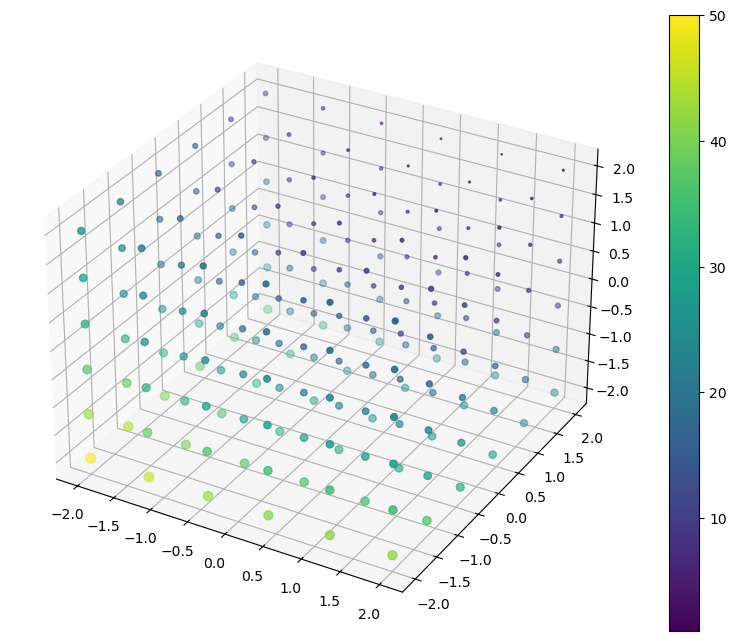

In [73]:
# Definindo a função do enunciado:
def f(x, y, z):
    return (x - 1)**2 + (y - 2)**2 + (z - 3)**2

# Gerarando os pontos da amostra (6 x 6 x 6 = 216 pontos no total)
N = 6
x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
z = np.linspace(-2, 2, N)
# Gerando o grid 3D contendo os 216 pontos com `meshgrid``:
X, Y, Z = np.meshgrid(x, y, z)

# Calculando os valores da função:
W = f(X, Y, Z)

# Criando a figura e o subplot:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")

# Plotando as coordenadas com tanto a cor quanto o tamanho de um
# ponto (x, y, z) na amostra definidos através do valor de f(x, y, z):
pontos = ax.scatter(X, Y, Z, c=W, s=W, cmap="viridis")
# Você pode omitir um dos argumentos `c=W` (para não colorir os pontos)
# ou `s=W` (para que todos os pontos tenham o mesmo tamanho).

# Adicionando uma barra de cores:
fig.colorbar(pontos)

plt.show()


### $ 3.2 $ Isosuperfícies

Recorde que um **conjunto de nível** $ L_c $ de uma função $ f \colon D \to
\mathbb R $ consiste de todos os pontos do seu domínio onde a função assume um
valor $ c $ dado:
$$
    L_c = f^{-1}(c) \subseteq D\,.
$$
Ou seja, $ L_c $ é a imagem inversa de $ c \in \mathbb R $. Quando $ f $
é uma função de duas variáveis, os conjuntos de nível são chamados de
*curvas de nível* (veja a $ \S 2 $), porque em geral estes conjuntos são curvas
(em $ \mathbb R^2 $).

Similarmente, se $ f $ é uma função de três variáveis,
então os conjuntos de nível são, em geral, superfícies bi-dimensionais contidas
no domínio de $ f $, e portanto em $ \mathbb R^3 $:
$$
    L_c = f^{-1}(c) = \{(x, y, z) \in D : f(x, y, z) = c \} \subseteq \mathbb R^3
$$
Neste contexto, estes conjuntos também são conhecidos como **isosuperfícies**. 
Para entender melhor como elas são obtidas, imagine fatiar o gráfico de uma função
$$
w = f(x, y, z)
$$
por uma série de hiperplanos paralelos em $ \mathbb R^4 $, de equações $ w = c\
\text{(constante)} $. As intersecções destes hiperplanos com o gráfico de $ f $ 
são (em geral) superfícies bi-dimensionais, cada uma representando a região do
domínio onde a função assume um valor constante diferente (no caso, $ c $).
Este método é muito útil para tentarmos inferir a
*forma* do gráfico da função (ainda que este seja um superfície $ 3D $ em
$ \mathbb R^4 $), por exemplo revelando "colinas" e "vales".

__Exemplo:__ Visualize as isosuperfícies da função
$$
w = f(x, y, z) = x^2 - 3y^2 + 2z^2
$$
definida no cubo domínio $ [-4, 4]^3 \subset \mathbb R^3 $
para $ 5 $ níveis $ c $ igualmente espaçados entre $ -30 $ e $ 50 $.

O Matplotlib não possui uma função nativa para visualização de isosuperfícies.
Por isto vamos usar aqui a biblioteca **Plotly**, que na verdade é mais adequada
para visualizações $ 3D $ em geral.

In [92]:
import plotly.graph_objects as go

x = np.linspace(-4, 4, 40)
y = np.linspace(-4, 4, 40)
z = np.linspace(-4, 4, 40)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

f = lambda x, y, z: x**2 - 3 * y**2 + 2 * z**2 
W = f(X, Y, Z)

fig = go.Figure(data=go.Isosurface(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=W.flatten(),
    isomin=-30,
    isomax=50,
    surface_count=5, # número de isosuperfícies, 2 por padrão: somente min e max
    colorbar_nticks=5, # marcações na barra de cores correspondendo aos valores
    caps=dict(x_show=False, y_show=False)
    ))
fig.show()